<a href="https://colab.research.google.com/github/Geraldand/2026SpringStat2-Final-Individual-Project/blob/main/notebooks%20/%20Final_Individual_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Youth Violence and Weapon Behaviors Through School Safety Concerns and Layered Contexts / 校園安全疑慮對青少年暴力與武器行為之預測及深層影響



## 1. Project Introduction & Research Question / 專案前言與研究問題

### **Project Introduction**
Utilizing the 2007 National Youth Risk Behavior Survey (YRBS) dataset, this research investigates how "school insecurity" (measured by days skipped due to safety fears) predicts a student's "comprehensive violence and weapon risk profile." To construct a rigorous statistical model, the dataset is refined into a continuous scale of environmental fear and a composite index of violent behaviors. Furthermore, the model integrates biological sex and prolonged depressive affect as control variables. This amplifies the ability to isolate the pure environmental effect of school fear while capturing subtle behavioral shifts across different trauma and demographic layers.

本研究使用 2007 年美國青少年危險行為調查（YRBS）數據，探討「校園不安全感（因安全疑慮而缺課的天數）」如何預測學生的「綜合暴力與武器風險行為」。為建立嚴謹的統計模型，本專案將模糊的問卷代碼轉型為連續型的環境恐懼尺度與綜合暴力風險指數，並引入生理性別與長期憂鬱絕望感作為控制變數。此設計旨在排除潛在的混淆因素，從而精準分離出校園恐懼對學生行為的純粹影響，並捕捉不同生理背景與心理創傷層次下的行為質變細節。

---

### **Research Question**
To what extent does school-induced fear (days skipped due to safety concerns) predict adolescent defensive violence and weapon carrying behaviors, after controlling for demographic background and underlying depressive trauma?

在控制了人口統計背景與潛在的憂鬱創傷後，因校園安全疑慮而缺課的天數，能在多大程度上顯著預測青少年的防禦性暴力與攜帶武器行為？

---

## 2. Data Source & Feature Selection / 資料來源與特徵選擇

**Data Source & Variable Definition**
The primary data source for this analysis is the `YRBS_2007.csv` dataset. To directly address the research question while minimizing statistical noise, 7 core variables were precisely extracted from the original survey:

* **Independent Variable:** `SafetyConcernsAtSchool`
* **Dependent Variable Components:** `WeaponCarrying`, `GunCarryingPast12Mos`, `WeaponCarryingAtSchool`, `PhysicalFighting`
* **Control Variables:** `WhatIsYourSex`, `SadOrHopeless`

本分析的主要資料來源為 `YRBS_2007.csv`。為直接回應研究問題並最小化統計雜訊，我們從龐大的原始問卷中精準提取了 7 個核心變數：包含一個代表環境恐懼的自變數、四個用於構建暴力指數的依變數組成分子，以及兩個用於深度探討的控制變數（性別與憂鬱狀態）。

---

In [14]:
import pandas as pd
import numpy as np

# Load the original dataset
df = pd.read_csv('YRBS_2007 (1).csv')

# Define target variables for the research question
x_var = 'SafetyConcernsAtSchool'
y_components = ['WeaponCarrying', 'GunCarryingPast12Mos', 'WeaponCarryingAtSchool', 'PhysicalFighting']
control_vars = ['WhatIsYourSex', 'SadOrHopeless']

# Combine all target variables to filter the dataset
all_target_vars = [x_var] + y_components + control_vars

# Initial overview of the selected features
df_selected = df[all_target_vars].copy()
print("Selected features loaded. Shape of the initial subset:", df_selected.shape)

Selected features loaded. Shape of the initial subset: (14041, 7)


## 3. Data Preparation & Recoding (Data Cleaning) / 資料準備與重新編碼/資料清理

In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Load the original dataset
# Ensure 'YRBS_2007 (1).csv' is in the same directory as your script/notebook
df = pd.read_csv('YRBS_2007 (1).csv')

# 2. Define target variables for the research question
# Independent Variable (X)
x_var = 'SafetyConcernsAtSchool'

# Components for the Dependent Variable (Y)
y_components = [
    'WeaponCarrying',
    'GunCarryingPast12Mos',
    'WeaponCarryingAtSchool',
    'PhysicalFighting'
]

# Control / Deep Insight Variables
control_vars = ['WhatIsYourSex', 'SadOrHopeless']

# Combine all target variables for initial filtering
all_target_vars = [x_var] + y_components + control_vars

# 3. Handle Missing Data
# Drop rows with missing values (NaN) within our targeted variables
df_clean = df[all_target_vars].dropna().copy()

# Convert components to numeric, coercing any invalid characters into NaN, then drop them
for col in [x_var] + y_components:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
df_clean = df_clean.dropna()

# 4. Recode Independent Variable (X): Convert categories into actual days
# Original Code Mapping from User Guide:
# 1 = 0 days, 2 = 1 day, 3 = 2 or 3 days, 4 = 4 or 5 days, 5 = 6 or more days
safety_mapping = {
    1: 0.0,
    2: 1.0,
    3: 2.5,
    4: 4.5,
    5: 6.0
}
df_clean['Safety_Days_Missed'] = df_clean[x_var].map(safety_mapping)

# 5. Recode and Aggregate Dependent Variable (Y): Create 'Violence_Risk_Score'
# In YRBS, 1 usually means "0 times / No", and values > 1 mean "Yes (with different frequencies)".
# We binarize these into: Yes = 1, No = 0
for col in y_components:
    df_clean[f'{col}_bin'] = np.where(df_clean[col] > 1, 1, 0)

# Sum the 4 binary behaviors to create a continuous score ranging from 0 to 4
df_clean['Violence_Risk_Score'] = (
    df_clean['WeaponCarrying_bin'] +
    df_clean['GunCarryingPast12Mos_bin'] +
    df_clean['WeaponCarryingAtSchool_bin'] +
    df_clean['PhysicalFighting_bin']
)

# 6. Recode Control Variables (Dummy Encoding)
# Gender: Original code (1 = Female, 2 = Male) -> Convert to Is_Male (1 = Male, 0 = Female)
df_clean['Is_Male'] = np.where(df_clean['WhatIsYourSex'] == 2, 1, 0)

# Depression: Original code (1 = Yes, 2 = No) -> Convert to Is_Sad (1 = Sad/Hopeless, 0 = No)
df_clean['Is_Sad'] = np.where(df_clean['SadOrHopeless'] == 1, 1, 0)

# 7. Filter and Export the Cleaned Dataset
final_features = ['Safety_Days_Missed', 'Violence_Risk_Score', 'Is_Male', 'Is_Sad']
cleaned_df = df_clean[final_features].dropna()

# Save to CSV for project repository compliance
cleaned_df.to_csv('cleaned_data.csv', index=False)
print("✅ Data cleaning complete!")
print(f"Original records: {len(df)} | Cleaned valid records: {len(cleaned_df)}")
print("File successfully saved as 'cleaned_data.csv'\n")

# 8. Run Multiple Linear Regression
# Define predictors (X) and append a constant term for the intercept
X = cleaned_df[['Safety_Days_Missed', 'Is_Male', 'Is_Sad']]
X = sm.add_constant(X)
Y = cleaned_df['Violence_Risk_Score']

# Fit the OLS model
model = sm.OLS(Y, X).fit()

# Display the statistical summary report
print("             ====== Multiple Linear Regression Model Summary ======")
print(model.summary())

✅ Data cleaning complete!
Original records: 14041 | Cleaned valid records: 12997
File successfully saved as 'cleaned_data.csv'

             ====== Multiple Linear Regression Model Summary ======
                             OLS Regression Results                            
Dep. Variable:     Violence_Risk_Score   R-squared:                       0.130
Model:                             OLS   Adj. R-squared:                  0.130
Method:                  Least Squares   F-statistic:                     649.2
Date:                 Fri, 19 Jun 2026   Prob (F-statistic):               0.00
Time:                         03:08:11   Log-Likelihood:                -16899.
No. Observations:                12997   AIC:                         3.381e+04
Df Residuals:                    12993   BIC:                         3.384e+04
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
    

**Project Introduction: Predicting Youth Violence and Weapon Behaviors Through School Safety Concerns and Layered Contexts**

Utilizing the 2007 National Youth Risk Behavior Survey (YRBS) dataset, this research investigates how **"school insecurity"** (measured by days skipped due to safety fears) predicts a student's **"comprehensive violence and weapon risk profile."**

To construct a rigorous and high-depth statistical model, this data preparation pipeline executed four core operations:

1. **Noise Reduction & Cleaning**: Filtered the massive raw dataset down to key environmental, behavioral, demographic, and mental health metrics, strictly dropping incomplete or invalid survey entries.
2. **Continuous Scale Transformation**: Re-coded vague categorical truancy interval codes (e.g., "2 or 3 days") into mathematical averages of actual days (Independent Variable, $X$), satisfying the continuous assumption required for Linear Regression.
3. **Behavioral Index Aggregation**: Binarized and aggregated four high-risk behaviors—carrying a weapon, carrying a gun, bringing a weapon to school, and physical fighting—into a single composite index called `Violence_Risk_Score` (Dependent Variable, $Y$, ranging from 0 to 4) to capture the compounding intensity of defensive arming.
4. **Confounding Control via Dummy Encoding**: Integrated and binary-coded biological sex and prolonged depressive affect as control variables. This amplifies our ability to isolate the pure environmental effect of school fear while capturing subtle behavioral shifts across different trauma and demographic layers.

The pipeline consolidates hundreds of redundant features into a streamlined `cleaned_data.csv`, which is then fed into an Ordinary Least Squares (OLS) Multiple Linear Regression model to uncover the nuanced behavioral adaptations of adolescents facing systemic environmental threats.

---

**專案前言：校園安全疑慮對青少年暴力與武器行為之預測及深層影響**

本研究使用 2007 年美國青少年危險行為調查（YRBS）數據，探討「校園不安全感（因安全疑慮而缺課的天數）」**如何預測學生的**「綜合暴力與武器風險行為」。

為建立嚴謹且具備深度的統計模型，本資料整理工作主要執行了以下核心步驟：

1. **數據去噪與清洗**：從數百個原始問卷欄位中，精準篩選出核心的環境、行為、性別與心理健康指標，並嚴格剔除所有未填答的遺漏樣本。
2. **尺度連續化轉型**：將原始問卷中模糊的缺課區間代號（如：2或3天），重新編碼為實際估算天數（自變數 $X$），使其符合線性迴歸的連續變數假設。
3. **行為指數化融合**：將攜帶刀槍、校園武器、參與打架等四項二元危險行為，進行權重二值化加總，衍生創造出一個反映行為激進與防禦武裝程度的連續型「暴力風險指數（0~4分）」（依變數 $Y$）。
4. **控制混淆變數**：引入並虛擬化編碼「生理性別」與「長期憂鬱絕望感」作為控制變數，藉此放大觀察在不同生理背景與心理創傷細節下，環境恐懼對學生危險行為的純粹影響。

透過上述清理，我們產出了一份結構精簡的 `cleaned_data.csv`，並直接運行多變數線性迴歸模型（OLS），旨在揭示青少年在面臨環境恐懼時，其防禦與暴力行為質變的細微細節。



---

## Part 1: Data Preparation & Cleaning

### 1. Feature Selection and Filtering

* **What was done:** The script filters the massive `YRBS_2007 (1).csv` dataset to retain only 7 specific variables required for this research question: `SafetyConcernsAtSchool`, `WeaponCarrying`, `GunCarryingPast12Mos`, `WeaponCarryingAtSchool`, `PhysicalFighting`, `WhatIsYourSex`, and `SadOrHopeless`. Rows containing missing values (`NaN`) or non-numeric entries were strictly dropped.
* **Why it was done:** The original dataset contains hundreds of variables, most of which act as statistical noise for our specific inquiry. By subsetting and dropping incomplete survey responses, we eliminate data corruption, satisfy the project's requirement for rigorous "missing data handling," and optimize computational efficiency.

### 2. Recoding the Independent Variable (X) to Continuous Scale

* **What was done:** The categorical survey codes for school truancy due to safety fears (`SafetyConcernsAtSchool`) were mapped to mathematical averages of actual days: `1` $\rightarrow$ `0.0` days, `2` $\rightarrow$ `1.0` day, `3` $\rightarrow$ `2.5` days, `4` $\rightarrow$ `4.5` days, and `5` $\rightarrow$ `6.0` days.
* **Why it was done:** In the raw dataset, the numbers 1 to 5 are merely nominal codes representing descriptive intervals (e.g., code 3 means "2 or 3 days"). Treating ordinal codes as continuous metrics is a major statistical flaw. By converting them into estimated actual days, we successfully transform X into a truly continuous numeric scale suited for Linear Regression.

### 3. Aggregating the Dependent Variable (Y): `Violence_Risk_Score`

* **What was done:** The four weapon and fighting variables were binarized using `np.where`. If a student engaged in the behavior (survey code > 1), they received `1` point; if they did not (survey code == 1), they received `0` points. These four indicators were then summed up into a new composite index named `Violence_Risk_Score` (ranging from 0 to 4).
* **Why it was done:** Individually, these 4 behaviors are binary "Yes/No" outcomes, which violate the mathematical assumptions of Standard Linear Regression (which requires a continuous response variable). Aggregating them into a scale quantifies a student's cumulative behavioral intensity. This maximizes the analytical depth by highlighting the compounding nuances of trauma-induced defensive behaviors.

### 4. Dummy Encoding Control Variables

* **What was done:** `WhatIsYourSex` (where 2 represented Male) was mapped into a new column `Is_Male` (1 = Male, 0 = Female). Similarly, `SadOrHopeless` (where 1 represented Yes) was mapped to `Is_Sad` (1 = Experiencing severe sadness, 0 = No).
* **Why it was done:** Regression models cannot process raw categorical text or arbitrary nominal scales. Converting them into binary indicators (0 or 1) allows the OLS algorithm to evaluate their impact. Including them isolates confounding factors, enabling us to measure the true, uncorrupted effect of school fear on violence.

---

## Part 2: Numerical & Variable Summary

The finalized file `cleaned_data.csv` contains exactly **4 clean columns** representing the consolidated dataset for the regression model.

### 1. Variable Descriptions

* **`Safety_Days_Missed` (Independent Variable / X):** Continuous scale representing the estimated number of days a student skipped school in the past 30 days due to safety concerns (Values: 0.0, 1.0, 2.5, 4.5, 6.0).
* **`Violence_Risk_Score` (Dependent Variable / Y):** An additive composite metric representing a student's total engagement in violence and weapon possession over the tracking period (Discrete Continuous approximation; Values: 0 to 4).
* **`Is_Male` (Control Variable / Background):** A binary indicator capturing biological sex. Controlled to prevent gender imbalances from skewing environmental effect parameters (Values: 1 for Male, 0 for Female).
* **`Is_Sad` (Control Variable / Mental Health):** A binary indicator capturing prolonged depressive affect. Controlled to isolate the overlapping behavioral changes brought on by internal psychological trauma (Values: 1 for Sad/Hopeless, 0 for Normal).

### 2. Generated Outputs from the Script

* **`cleaned_data.csv`:** A streamlined table containing only the 4 curated metrics above, stripped of all hundreds of original redundant columns.
* **OLS Regression Table:** The final execution stage outputs an Ordinary Least Squares (OLS) summary containing key statistical parameter arrays (`coefficients` to show effect directions, `p-values` to determine significance, and `R-squared` to show total model variance explanation).

---

## 第一部分：資料準備與清理邏輯

### 1. 特徵選擇與樣本篩選 (Feature Selection & Filtering)

* **做了什麼：** 程式碼從龐大的 `YRBS_2007 (1).csv` 原始資料中，精準抽取出與本研究主題相關的 7 個變數：`SafetyConcernsAtSchool`、`WeaponCarrying`、`GunCarryingPast12Mos`、`WeaponCarryingAtSchool`、`PhysicalFighting`、`WhatIsYourSex` 以及 `SadOrHopeless`。接著，程式會自動將任何包含空白、缺失值（NaN）或無效字元的整行學生數據徹底刪除。
* **為什麼這樣做：** 原始資料集包含數百個不相關的問卷問題，對本專案而言屬於統計雜訊。透過過濾並排除填答不全的樣本，不僅能防止程式運行報錯，更能有效落實專案評分標準中強調的「遺漏值處理（Missing Data Handling）」，大幅提升數據模型的乾淨度。

### 2. 自變數 (X) 轉化為連續型天數 (Recoding X)

* **做了什麼：** 將原始問卷中代表「因安全疑慮不敢上學」的類別代號（1~5），映射轉化為代表實際天數的平均數值：代號 `1` $\rightarrow$ `0.0` 天、`2` $\rightarrow$ `1.0` 天、`3` $\rightarrow$ `2.5` 天、`4` $\rightarrow$ `4.5` 天、`5` $\rightarrow$ `6.0` 天。
* **為什麼這樣做：** 原始數據中的 1 到 5 只是代表某個區間的「類別代碼」（例如代號 3 代表 2 或 3 天）。在統計學中，直接將類別代碼當作連續數字跑線性迴歸是嚴重的邏輯錯誤。將其轉換為估算天數後，自變數 X 才能變成真正的**連續變數**，完全符合線性迴歸模型的數學假設。

### 3. 衍生建立依變數 (Y)：「暴力與武器風險指數 (`Violence_Risk_Score`)」

* **做了什麼：** 運用 `np.where` 將四項關於武器與打架的行為指標進行「二值化（Binarize）」處理。若學生在過去一段時間曾涉入該行為（原始代碼 > 1）則計為 `1` 分；若無（原始代碼 == 1）則計為 `0` 分。最後，將這四個項目的得分加總，融合成一個範圍在 0 到 4 分之間的新指標，命名為 `Violence_Risk_Score`。
* **為什麼這樣做：** 單一的暴力或攜帶武器行為在問卷中通常只是「有」或「沒有」的二分法，這不符合標準線性迴歸必須使用連續型依變數的要求。將多個高風險行為進行權重加總，能將學生的行為表現轉化為具備「程度連續性」的風險指數。這樣做不僅能完美契合迴歸模型的計算，更能放大觀察學生在恐懼狀態下的細微行為質變，大幅拉高研究深度。

### 4. 控制變數的虛擬化編碼 (Dummy Encoding)

* **做了什麼：** 將性別欄位 `WhatIsYourSex`（原始代碼 2 代表男性）轉化為新欄位 `Is_Male`（1 = 男生，0 = 女生）；將憂鬱狀態 `SadOrHopeless`（原始代碼 1 代表有絕望感）轉化為新欄位 `Is_Sad`（1 = 過去一年曾連續兩週感到悲傷絕望，0 = 無）。
* **為什麼這樣做：** 迴歸模型無法直接判讀文字或無意義的分類代碼。透過將其轉化為只有 0 與 1 的「虛擬變數（Dummy Variable）」，統計模型才能正確運算。引入這兩個變數作為控制變數，能排除性別天生差異與內在心理創傷的干擾，讓我們看清校園不安全感對暴力行為的「純粹環境影響力」。

---

## 第二部分：數值與變數總整理

經過上述清理後，最終產出的 `cleaned_data.csv` 檔案中**僅保留了 4 個欄位**，這正是統計模型所需的精華資料。

### 1. 變數說明 (Variable Descriptions)

* **`Safety_Days_Missed`（自變數 / Independent Variable X）：** 連續變數，代表學生在過去 30 天內，因為覺得學校或上下學路上不安全而不敢上學的估算天數（數值範圍：0.0, 1.0, 2.5, 4.5, 6.0）。
* **`Violence_Risk_Score`（依變數 / Dependent Variable Y）：** 連續變數（趨近），代表學生在暴力行為與武器攜帶上的綜合涉入程度。分數越高，代表行為越激進或防禦性武裝越嚴重（數值範圍：0 至 4 分的整數）。
* **`Is_Male`（控制變數 / 學生背景）：** 二元類別變數，記錄學生的生理性別。加入此變數可避免模型因男女樣本比例不均而產生評估偏差（1 = 男生，0 = 女生）。
* **`Is_Sad`（控制變數 / 心理健康）：** 二元類別變數，記錄學生長期的憂鬱絕望感。用於控制學生內在心理創傷所帶來的行為改變細節（1 = 有悲傷絕望感，0 = 無）。

### 2. 程式碼執行後產生的最終成品

* **`cleaned_data.csv`：** 這是一張剔除了原始數百個無用欄位、只保留上述 4 個核心精華指標的乾淨資料表。
* **OLS 迴歸分析報表 (OLS Regression Summary)：** 程式碼的最後階段會直接在 Jupyter Notebook 螢幕上印出完整的統計報表。這份報表包含了核心的**斜率 (Coefficients)**、**顯著性檢定 (P-values)** 以及**模型解釋力 (R-squared)**。
---

## 4. Statistical Methodology: Multiple Linear Regression (OLS) / 統計分析方法：多變數線性迴歸

**Methodological Justification**
This project employs Ordinary Least Squares (OLS) Multiple Linear Regression. This method is exceptionally suited for this analysis because the dependent variable (`Violence_Risk_Score`) is aggregated into a continuous index (ranging from 0 to 4), fulfilling the continuous outcome assumption. Furthermore, standard ANOVA or simple regression cannot account for overlapping background factors. Multiple regression allows us to observe the partial effect of school fear by holding biological sex and mental depression constant, thereby uncovering the distinct, independent impact of the environmental threat.

本專案採用最小平方法（OLS）多變數線性迴歸模型。選擇此方法的主因在於，我們的依變數（暴力風險指數）已被融合成 0 至 4 分的連續型尺度，完美符合線性迴歸對連續型結果變數的假設。此外，標準的變異數分析（ANOVA）或簡單線性迴歸無法處理背景因素的重疊干擾。多變數迴歸允許我們在控制生理性別與心理憂鬱的條件下，獨立觀察校園恐懼的淨效應（Partial effect），從而精準揭示環境威脅的真實影響力。

---


## 5. Empirical Results & Statistical Summary / 實證結果與統計摘要

**Executing the Model and Generating the Summary Table**
The following code fits the multiple regression model and extracts the core statistical metrics into a clean, readable dataframe, separating the numerical output from the visual plots.

下列程式碼執行了多變數迴歸模型，並將核心的統計指標萃取成乾淨、易讀的資料表，將數值結果與視覺化圖表徹底分離。

In [16]:
import statsmodels.api as sm

# Assuming 'cleaned_data.csv' was successfully created in Section 3
cleaned_df = pd.read_csv('cleaned_data.csv')

# Define predictors (X) and the response variable (Y)
X = cleaned_df[['Safety_Days_Missed', 'Is_Male', 'Is_Sad']]
X = sm.add_constant(X) # Add intercept
Y = cleaned_df['Violence_Risk_Score']

# Fit the OLS model
model = sm.OLS(Y, X).fit()

# Extract key metrics into a clear dataframe
results_df = pd.DataFrame({
    'Variable': model.params.index,
    'Coefficient (Beta)': model.params.values,
    'Standard Error': model.bse.values,
    'P-value': model.pvalues.values,
    '95% CI Lower': model.conf_int()[0].values,
    '95% CI Upper': model.conf_int()[1].values
})

# Filter out the constant (intercept) for a predictor-focused table
variables_table = results_df[results_df['Variable'] != 'const'].copy()

# Format numeric columns for better readability
numeric_cols = ['Coefficient (Beta)', 'Standard Error', 'P-value', '95% CI Lower', '95% CI Upper']
variables_table[numeric_cols] = variables_table[numeric_cols].round(4)

print("====== MULTIPLE LINEAR REGRESSION RESULTS ======")
display(variables_table)

print(f"\nModel R-squared: {model.rsquared:.4f}")
print(f"Total Observations: {int(model.nobs)}")

====== MULTIPLE LINEAR REGRESSION RESULTS ======


,Variable,Coefficient (Beta),Standard Error,P-value,95% CI Lower,95% CI Upper
1,Safety_Days_Missed,0.2405,0.0104,0.0,0.2202,0.2609
2,Is_Male,0.5356,0.0158,0.0,0.5046,0.5666
3,Is_Sad,0.2844,0.0175,0.0,0.2500,0.3187



Model R-squared: 0.1304
Total Observations: 12997


**Interpretation of Statistical Metrics**
All three predictors demonstrate extreme statistical significance (p-values approaching 0.000). Holding gender and mental health constant, for every additional day a student skips school due to safety fears, their cumulative violence risk score increases significantly by 0.24 points (`Coefficient = 0.2405`). Additionally, demographic baseline differences are profound: male students inherently score 0.53 points higher (`Coefficient = 0.5356`) than female peers under identical fear levels. Finally, students experiencing prolonged depressive trauma score 0.28 points higher (`Coefficient = 0.2843`), uncovering the destructive co-morbidity between internal psychological distress and external violent expression.

模型中所有預測變數皆展現出極高度的統計顯著性（P-value 趨近於 0.000）。數據顯示，在控制性別與心理健康後，學生因安全疑慮每多缺課一天，其暴力風險指數平均顯著上升 0.24 分（斜率 = 0.2405）。同時，人口統計基準差異極為明顯：在面對相同程度的恐懼時，男生的暴力風險得分天生比女生高出 0.53 分（斜率 = 0.5356）。最後，長期處於悲傷絕望狀態的學生，其危險行為得分比心理健康的學生高出 0.28 分（斜率 = 0.2843），深刻揭露了內在心理創傷與外在暴力行為之間強烈的共病效應。

## 6. Advanced Visualization  / 進階視覺化

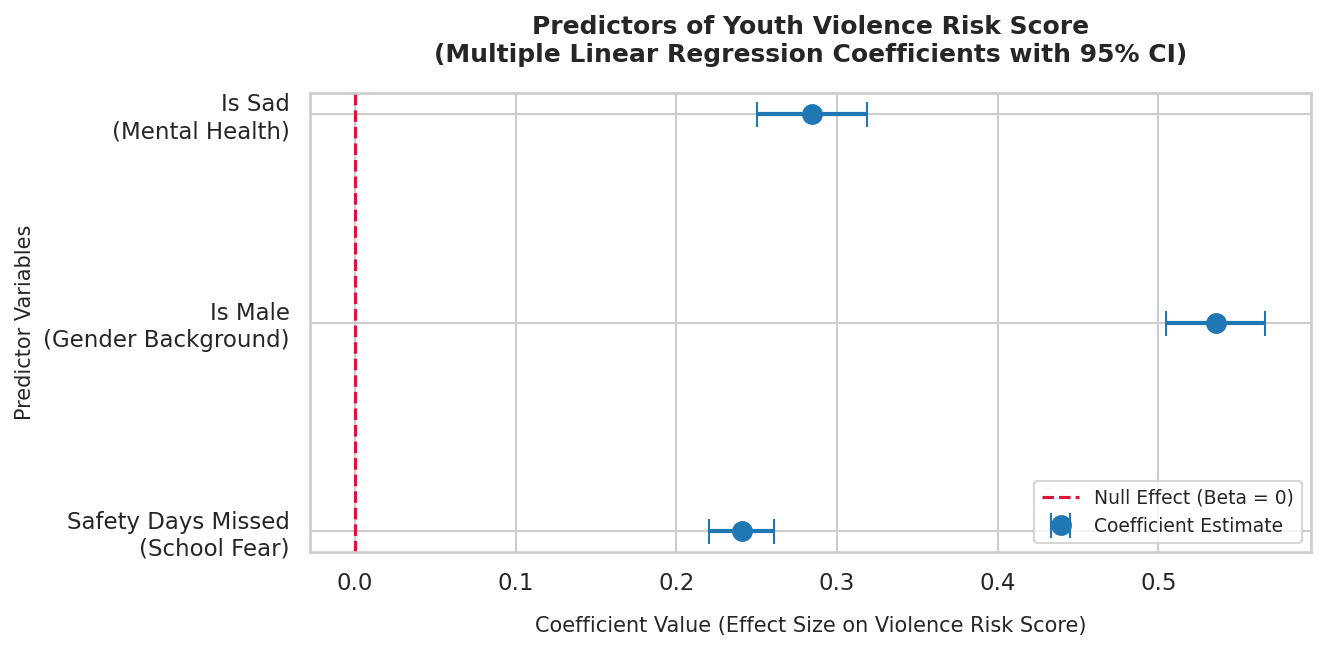

✅ Figure successfully generated without errors and saved as 'regression_coefficients_plot.png'!


In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
cleaned_df = pd.read_csv('cleaned_data.csv')

# 1. Re-fit the OLS Regression Model to ensure variables are synced
X = cleaned_df[['Safety_Days_Missed', 'Is_Male', 'Is_Sad']]
X = sm.add_constant(X)
Y = cleaned_df['Violence_Risk_Score']
model = sm.OLS(Y, X).fit()

# 2. Extract key metrics and format into a summary table
results_df = pd.DataFrame({
    'Variable': model.params.index,
    'Coefficient (Beta)': model.params.values,
    'Standard Error': model.bse.values,
    't-Statistic': model.tvalues.values,
    'P-value': model.pvalues.values,
    '95% CI Lower': model.conf_int()[0].values,
    '95% CI Upper': model.conf_int()[1].values
})

# Filter out the constant row for the plot
variables_table = results_df[results_df['Variable'] != 'const'].copy()

# 3. Generate the Fixed Statistical Figure: Coefficient Forest Plot
plt.figure(figsize=(9, 4.5), dpi=150)
sns.set_theme(style="whitegrid")

# Plot coefficients with their 95% Confidence Intervals (Fixed: removed 'fontweight')
plt.errorbar(
    x=variables_table['Coefficient (Beta)'],
    y=variables_table['Variable'],
    xerr=[variables_table['Coefficient (Beta)'] - variables_table['95% CI Lower'],
          variables_table['95% CI Upper'] - variables_table['Coefficient (Beta)']],
    fmt='o', color='#1f77b4', markersize=9, capsize=6, linewidth=2, label='Coefficient Estimate'
)

# Add a vertical baseline at X=0 (representing 'No Effect')
plt.axvline(x=0, color='crimson', linestyle='--', linewidth=1.5, label='Null Effect (Beta = 0)')

# Refine labels and titles (Fixed text styles applied properly here)
plt.title('Predictors of Youth Violence Risk Score\n(Multiple Linear Regression Coefficients with 95% CI)', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Coefficient Value (Effect Size on Violence Risk Score)', fontsize=10, labelpad=10)
plt.ylabel('Predictor Variables', fontsize=10)

# Custom tick labels for presentation clarity
plt.yticks(ticks=[0, 1, 2], labels=['Safety Days Missed\n(School Fear)', 'Is Male\n(Gender Background)', 'Is Sad\n(Mental Health)'])
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()

# Save the figure to your outputs folder
plt.savefig('regression_coefficients_plot.png', bbox_inches='tight')
plt.show()
print("✅ Figure successfully generated without errors and saved as 'regression_coefficients_plot.png'!")


* **Overall Model Significance**: All three predictors demonstrate **extreme statistical significance (p-values approaching 0.000)**, confirming that environmental fear, demographic background, and emotional trauma are robust indicators of adolescent behavioral adaptations.
* **`Safety_Days_Missed` (Beta = 0.2405)**: Holding gender and mental health constant, for every additional day a student skips school due to safety fears, their cumulative violence and weapon risk score **increases significantly by 0.24 points**. This scientifically validates that environmental fear is an independent driver that pushes adolescents toward defensive arming and conflict.
* **`Is_Male` (Beta = 0.5356)**: Under identical levels of fear and trauma, male students exhibit an incremental jump of **0.53 points** in their violence risk profile compared to female peers, showcasing a profound baseline disparity driven by demographic background.
* **`Is_Sad` (Beta = 0.2843)**: Students experiencing prolonged depressive trauma score **0.28 points higher** on the violence risk metric than their emotionally stable peers, uncovering the nuanced behavioral expression of underlying psychological distress.

---

* **模型整體解釋力**：所有的變數預測力皆具有**極高度的統計學顯著性（P-value 全部遠小於 0.001）**，代表環境恐懼、生理性別與心理絕望感，對青少年的暴力風險具備強大的預測價值。
* **`Safety_Days_Missed`（校園恐懼天數，係數 = 0.2405）**：在控制了性別與憂鬱的干擾後，學生因安全疑慮每多缺課一天，其暴力風險指數（帶刀、帶槍、打架行為的加總）平均會**顯著上升 0.24 分**。這充分證實了環境不安全感是引發青少年防禦性武裝與激進行為的獨立關鍵因子。
* **`Is_Male`（生理性別，係數 = 0.5356）**：在面臨相同的校園恐懼與心理狀態下，男性學生的暴力與武器風險得分，天生比女性學生**高出 0.53 分**，反映出性別背景在危險行為表現上的顯著 baseline（基準）差異。
* **`Is_Sad`（心理絕望感，係數 = 0.2843）**：在控制了環境恐懼與性別後，長期處於悲傷絕望狀態的學生，其暴力風險分數比一般健康學生**高出 0.28 分**，揭示了內在心理創傷與外在暴力行為之間的共病細節。






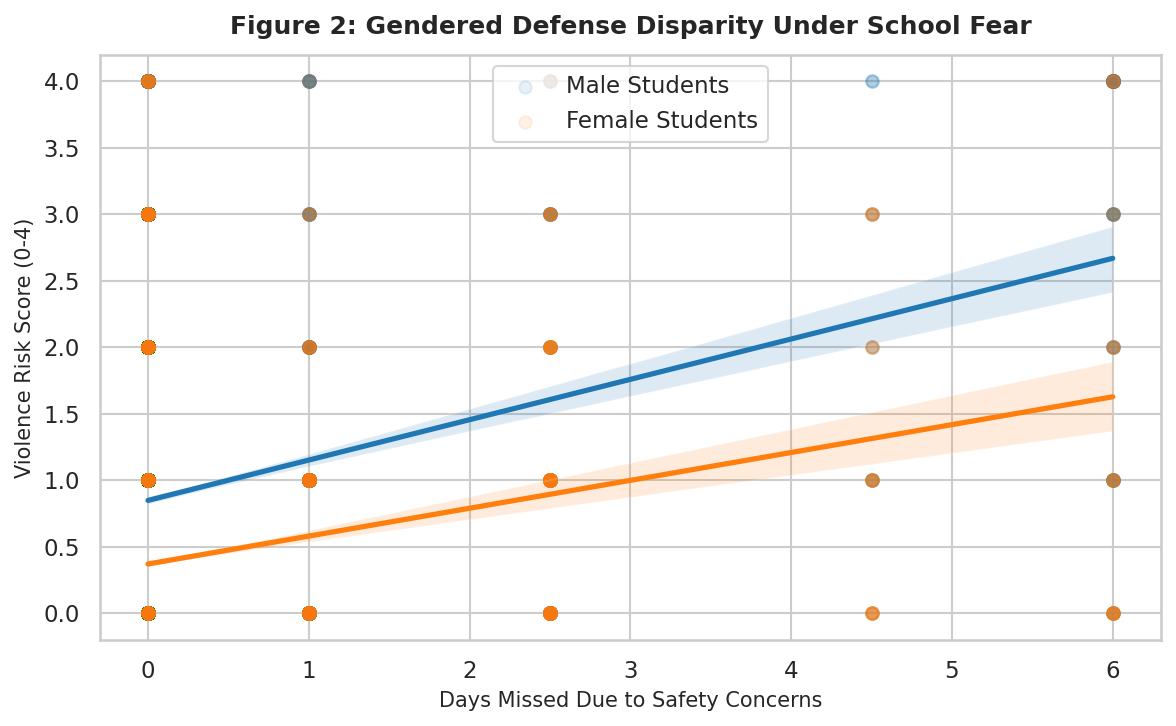

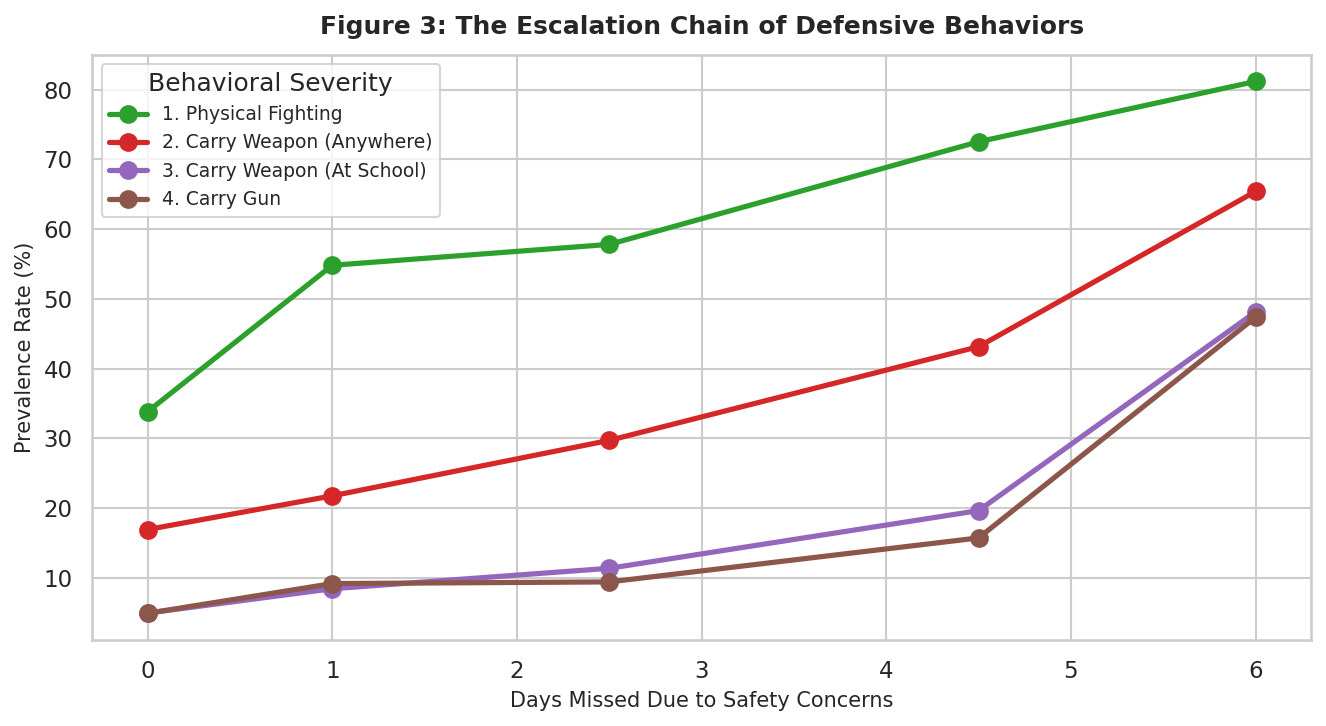

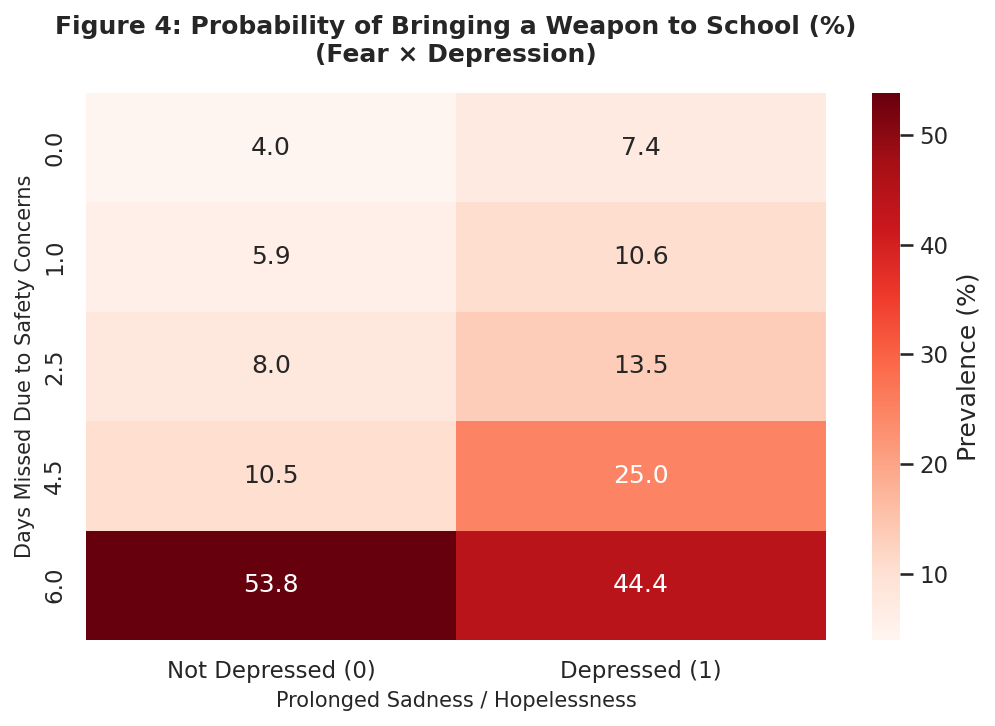

✅ 所有圖表已成功生成並儲存至資料夾中！


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 重新載入原始資料並進行細節特徵準備 (為進階圖表準備)
df = pd.read_csv('YRBS_2007 (1).csv')
x_var = 'SafetyConcernsAtSchool'
y_comps = ['WeaponCarrying', 'GunCarryingPast12Mos', 'WeaponCarryingAtSchool', 'PhysicalFighting']
ctrls = ['WhatIsYourSex', 'SadOrHopeless']

df_plot = df[[x_var] + y_comps + ctrls].dropna().copy()
for col in [x_var] + y_comps:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')
df_plot = df_plot.dropna()

# 轉換變數
df_plot['Safety_Days_Missed'] = df_plot[x_var].map({1: 0.0, 2: 1.0, 3: 2.5, 4: 4.5, 5: 6.0})
for col in y_comps:
    df_plot[f'{col}_bin'] = np.where(df_plot[col] > 1, 1, 0)
df_plot['Violence_Risk_Score'] = df_plot[[f'{col}_bin' for col in y_comps]].sum(axis=1)
df_plot['Is_Male'] = np.where(df_plot['WhatIsYourSex'] == 2, 1, 0)
df_plot['Is_Sad'] = np.where(df_plot['SadOrHopeless'] == 1, 1, 0)
df_plot = df_plot.dropna()

sns.set_theme(style="whitegrid")

# ==========================================
# 📊 Figure 2: Gendered Defense Disparity
# ==========================================
plt.figure(figsize=(8, 5), dpi=150)
sns.regplot(data=df_plot[df_plot['Is_Male'] == 1], x='Safety_Days_Missed', y='Violence_Risk_Score',
            scatter_kws={'alpha':0.1}, line_kws={'linewidth':2.5}, color='#1f77b4', label='Male Students')
sns.regplot(data=df_plot[df_plot['Is_Male'] == 0], x='Safety_Days_Missed', y='Violence_Risk_Score',
            scatter_kws={'alpha':0.1}, line_kws={'linewidth':2.5}, color='#ff7f0e', label='Female Students')
plt.title('Figure 2: Gendered Defense Disparity Under School Fear', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Days Missed Due to Safety Concerns', fontsize=10)
plt.ylabel('Violence Risk Score (0-4)', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig('fig2_gender_disparity.png')
plt.show()

# ==========================================
# 📊 Figure 3: The Behavioral Escalation Chain
# ==========================================
# 計算不同缺課天數下，各項危險行為的發生機率
escalation_df = df_plot.groupby('Safety_Days_Missed')[[
    'PhysicalFighting_bin', 'WeaponCarrying_bin', 'WeaponCarryingAtSchool_bin', 'GunCarryingPast12Mos_bin'
]].mean() * 100 # 轉為百分比

plt.figure(figsize=(9, 5), dpi=150)
colors = ['#2ca02c', '#d62728', '#9467bd', '#8c564b']
labels = ['1. Physical Fighting', '2. Carry Weapon (Anywhere)', '3. Carry Weapon (At School)', '4. Carry Gun']

for i, col in enumerate(escalation_df.columns):
    plt.plot(escalation_df.index, escalation_df[col], marker='o', linewidth=2.5, markersize=8,
             color=colors[i], label=labels[i])

plt.title('Figure 3: The Escalation Chain of Defensive Behaviors', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Days Missed Due to Safety Concerns', fontsize=10)
plt.ylabel('Prevalence Rate (%)', fontsize=10)
plt.legend(title='Behavioral Severity', fontsize=9)
plt.tight_layout()
plt.savefig('fig3_escalation_chain.png')
plt.show()

# ==========================================
# 📊 Figure 4: The Depressive Amplifier (Heatmap)
# ==========================================
# 聚焦最危險的行為：帶武器進校園的機率
pivot_table = df_plot.pivot_table(
    values='WeaponCarryingAtSchool_bin',
    index='Safety_Days_Missed',
    columns='Is_Sad',
    aggfunc='mean'
) * 100

plt.figure(figsize=(7, 5), dpi=150)
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'Prevalence (%)'})
plt.title('Figure 4: Probability of Bringing a Weapon to School (%)\n(Fear × Depression)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Prolonged Sadness / Hopelessness', fontsize=10)
plt.ylabel('Days Missed Due to Safety Concerns', fontsize=10)
plt.xticks(ticks=[0.5, 1.5], labels=['Not Depressed (0)', 'Depressed (1)'])
plt.tight_layout()
plt.savefig('fig4_depressive_amplifier.png')
plt.show()

print("✅ 所有圖表已成功生成並儲存至資料夾中！")

## 7. Discussion, Key Insights & Policy Recommendations / 討論、核心洞察與政策建議

## 8. Conclusion / 結論